In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib import rc
import time


## Question 1

### Question 1a

In [112]:
# import polblog data
G = nx.DiGraph()
with open('data/polblogs_nodes_class.tsv','r') as fp:
    for line in fp:
        node_id, node_label, node_political = line.strip().split('\t')
        political_orientation = 'liberal' if node_political == '0' else 'conservative'
        G.add_node(node_id, website=node_label, political_orientation=political_orientation)

with open('data/polblogs_edges_class.tsv','r') as fp:
    for line in fp:
        source_node_id, target_node_id = line.strip().split('\t')
        G.add_edge(source_node_id, target_node_id)

In [113]:
print("Number of nodes: %d" % G.number_of_nodes())
print("Number of edges: %d" % G.number_of_edges())
print("Graph density:\t %1.7f" % nx.density(G))

Number of nodes: 1490
Number of edges: 19025
Graph density:	 0.0085752


In [114]:

# Write all the edgelists
import json
import pickle

# Edgelist
nx.write_edgelist(G, "outputs/polblogs.edgelist")

# GraphML
nx.write_graphml(G, "outputs/polblogs.graphml")

#JSON
json_graph = nx.node_link_data(G)
with open("outputs/polblogs.json", "w", encoding="utf-8") as gfile:
    json.dump(json_graph, gfile)

# Pickle binary serialization
with open("outputs/polblogs.pkl", 'wb') as gfile:
    pickle.dump(G, gfile)

# dense adjacency matrix
nmp = nx.to_numpy_array(G)
with open("outputs/polblogs.npy", 'wb') as gfile:
    np.save(gfile, nmp)


In [5]:
# Read in data
import os

# First, write the original network's information
# Now save everything to a file for easy viewing 
with open("outputs/network_info.txt", 'w') as info_file:
    info_file.write(f"Network: G \n")
    info_file.write(f"Node Count: {G.number_of_nodes()}\n")
    info_file.write(f"Edge Count: {G.number_of_edges()}\n")
    info_file.write(f"Is directed: {nx.is_directed(G)}\n")
    info_file.write(f"Website Attr Length: {len(nx.get_node_attributes(G, 'website'))}\n")
    info_file.write(f"Political Orientation Attr Length: {len(nx.get_node_attributes(G, 'political_orientation'))}\n")
    info_file.write(f"Graphs are equal: {nx.utils.graphs_equal(G, G)}\n") 
    info_file.write(f"\n\n")

network_list = list()
suffixes = ["edgelist", "graphml", "json", "pkl", "npy"]

# Edgelist
network_list.append(nx.read_edgelist("outputs/polblogs.edgelist"))

# GraphML
network_list.append(nx.read_graphml("outputs/polblogs.graphml"))

# JSON
with open('outputs/polblogs.json', 'r', encoding='utf-8') as file:
    node_link_data = json.load(file)
network_list.append(nx.node_link_graph(node_link_data))

# Pickle binary serialization
with open("outputs/polblogs.pkl", 'rb') as gfile:
    network_list.append(pickle.load(gfile))

# NP dense ajacency matrix
with open("outputs/polblogs.npy", 'rb') as gfile:
    back_np = np.load(gfile)
    network_list.append(nx.from_numpy_array(back_np))

# Now save everything to the file for easy viewing 
with open("outputs/network_info.txt", 'a') as info_file:
    for i, network in enumerate(network_list):
        info_file.write(f"Network: {suffixes[i]} \n")
        info_file.write(f"File size: {round(os.path.getsize(f'outputs/polblogs.{suffixes[i]}') / 1024)} kilobytes \n")
        info_file.write(f"Node Count: {network.number_of_nodes()}\n")
        info_file.write(f"Edge Count: {network.number_of_edges()}\n")
        info_file.write(f"Is directed: {nx.is_directed(network)}\n")
        info_file.write(f"Website Attr Length: {len(nx.get_node_attributes(network, 'website'))}\n")
        info_file.write(f"Political Orientation Attr Length: {len(nx.get_node_attributes(network, 'political_orientation'))}\n")
        info_file.write(f"Graphs are equal: {nx.utils.graphs_equal(G, network)}\n")
        info_file.write("\n\n")

### Question 1b

In [6]:
# Now check the specifics of the attributes 

# First, what is G?
print(f"Looking at network G")
attrs = nx.get_node_attributes(G, 'website')
print(f'Attribute storage type is {type(attrs)}')
print(f'Attribute type is {type(attrs["0"])}')
print(f"G nodes: {type(G.nodes)}")
print(("\n\n"))

# Now compare the others
for i, network in enumerate(network_list):
    attrs = nx.get_node_attributes(network, 'website')

    if(len(attrs) > 0):
        print(f"Looking at network {suffixes[i]}")
        print(f'Attribute storage type is {type(attrs)}')
        print(f'Attribute type is {type(attrs["0"])}')
        print(("\n"))

# Check np file
nparray = np.load('outputs/polblogs.npy')
nparray

Looking at network G
Attribute storage type is <class 'dict'>
Attribute type is <class 'str'>
G nodes: <class 'networkx.classes.reportviews.NodeView'>



Looking at network graphml
Attribute storage type is <class 'dict'>
Attribute type is <class 'str'>


Looking at network json
Attribute storage type is <class 'dict'>
Attribute type is <class 'str'>


Looking at network pkl
Attribute storage type is <class 'dict'>
Attribute type is <class 'str'>




array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1490, 1490))

### Question 1c

In [7]:
# Fix Edgelist
nx.write_edgelist(G, "outputs/polblogs_fixed.edgelist", data=["website", "political_orientation"],  delimiter=',')
edge_list = nx.read_edgelist("outputs/polblogs_fixed.edgelist", create_using=nx.DiGraph,  delimiter=',')

print(f"Network: edgelist")
print(f"File size: {round(os.path.getsize(f'outputs/polblogs_fixed.edgelist') / 1024)} kilobytes")
print(f"Node Count: {edge_list.number_of_nodes()}")
print(f"Edge Count: {edge_list.number_of_edges()}")
print(f"Is directed: {nx.is_directed(edge_list)}")
print(f"Website Attr Length: {len(nx.get_node_attributes(edge_list, 'website'))}")
print(f"Political Orientation Attr Length: {len(nx.get_node_attributes(edge_list, 'political_orientation'))}")
print(f"Graphs are equal: {nx.utils.graphs_equal(G, edge_list)}\n")

Network: edgelist
File size: 158 kilobytes
Node Count: 1224
Edge Count: 19025
Is directed: True
Website Attr Length: 0
Political Orientation Attr Length: 0
Graphs are equal: False



In [8]:
# Fix GraphML
nx.write_graphml(G, "outputs/polblogs_fixed.graphml")
GraphML_fixed = nx.read_graphml("outputs/polblogs_fixed.graphml")

print(f"Network: GraphML")
print(f"File size: {round(os.path.getsize(f'outputs/polblogs_fixed.graphml') / 1024)} kilobytes ")
print(f"Node Count: {GraphML_fixed.number_of_nodes()}")
print(f"Edge Count: {GraphML_fixed.number_of_edges()}")
print(f"Is directed: {nx.is_directed(GraphML_fixed)}")
print(f"Website Attr Length: {len(nx.get_node_attributes(GraphML_fixed, 'website'))}")
print(f"Political Orientation Attr Length: {len(nx.get_node_attributes(GraphML_fixed, 'political_orientation'))}")
print(f"Graphs are equal: {nx.utils.graphs_equal(G, GraphML_fixed)}\n")

# look for the differences
print(GraphML_fixed.nodes == G.nodes)
print(GraphML_fixed.edges == G.edges)
print(GraphML_fixed.edges == G.edges)
print(nx.get_node_attributes(GraphML_fixed, 'political_orientation')==nx.get_node_attributes(G, 'political_orientation'))
print(nx.get_node_attributes(GraphML_fixed, 'website')==nx.get_node_attributes(G, 'website'))

print("Looking at nodes and data....")
print(G.nodes(data=True) == GraphML_fixed.nodes(data=True))
#print(f"Same shape: {nx.is_isomorphic(G, GraphML_fixed)}")
print(type(G))
print(type(GraphML_fixed))


# Check IDs
node_ids = list(G)
graph_node_ids = list(GraphML_fixed)
print(graph_node_ids == node_ids)

# Everything checks out. Maybe some oddness with the python object itself. 
# Now check based on docstring
print("Looking at docstring evaluations...")
print(GraphML_fixed.adj == G.adj)
print(GraphML_fixed.nodes == G.nodes)
print(GraphML_fixed.graph == G.graph)
print("Done.")

# The graphs are not equal, let's print both
print(f"GraphM:: {GraphML_fixed.graph}")
print(f"Original: {G.graph}")

# The original is just an empty list. So reset 
GraphML_fixed.graph = {}
print("Updated new graph. Equal?")
print(GraphML_fixed.adj == G.adj)
print(GraphML_fixed.nodes == G.nodes)
print(GraphML_fixed.graph == G.graph)
print(nx.utils.graphs_equal(GraphML_fixed, G))
# Fixed it!

Network: GraphML
File size: 912 kilobytes 
Node Count: 1490
Edge Count: 19025
Is directed: True
Website Attr Length: 1490
Political Orientation Attr Length: 1490
Graphs are equal: False

True
True
True
True
True
Looking at nodes and data....
True
<class 'networkx.classes.digraph.DiGraph'>
<class 'networkx.classes.digraph.DiGraph'>
True
Looking at docstring evaluations...
True
True
False
Done.
GraphM:: {'node_default': {}, 'edge_default': {}}
Original: {}
Updated new graph. Equal?
True
True
True
True


In [9]:
# dense adjacency matrix
nmp = nx.to_numpy_array(G)
with open("outputs/polblogs_fixed.npy", 'wb') as gfile:
    np.save(gfile, nmp)

# NP dense ajacency matrix
# Pickle binary serialization
with open("outputs/polblogs_fixed.npy", 'rb') as gfile:
    back_np = np.load(gfile)
    np_network = nx.from_numpy_array(back_np, create_using=nx.DiGraph)

print(f"\n\nNetwork: NP Array")
print(f"File size: {round(os.path.getsize(f'outputs/polblogs_fixed.edgelist') / 1024)} kilobytes")
print(f"Node Count: {np_network.number_of_nodes()}")
print(f"Edge Count: {np_network.number_of_edges()}")
print(f"Is directed: {nx.is_directed(np_network)}")
print(f"Website Attr Length: {len(nx.get_node_attributes(np_network, 'website'))}")
print(f"Political Orientation Attr Length: {len(nx.get_node_attributes(np_network, 'political_orientation'))}")
print(f"Graphs are equal: {nx.utils.graphs_equal(G, np_network)}\n")



Network: NP Array
File size: 158 kilobytes
Node Count: 1490
Edge Count: 19025
Is directed: True
Website Attr Length: 0
Political Orientation Attr Length: 0
Graphs are equal: False



### Question 1e

In [10]:
baby_graph = nx.path_graph(5)
print(baby_graph.nodes(data=True))


[(0, {}), (1, {}), (2, {}), (3, {}), (4, {})]


In [11]:
# Edgelist
nx.write_edgelist(G, "outputs/baby_graph.edgelist")
baby_edge = nx.read_edgelist("outputs/baby_graph.edgelist")
baby_edge.nodes(data=True)
# labels stored as strings

NodeDataView({'0': {}, '22': {}, '54': {}, '84': {}, '154': {}, '322': {}, '366': {}, '433': {}, '482': {}, '574': {}, '640': {}, '641': {}, '643': {}, '663': {}, '1244': {}, '1434': {}, '1': {}, '17': {}, '23': {}, '28': {}, '51': {}, '98': {}, '143': {}, '153': {}, '158': {}, '171': {}, '179': {}, '203': {}, '237': {}, '247': {}, '331': {}, '362': {}, '388': {}, '390': {}, '430': {}, '445': {}, '476': {}, '494': {}, '543': {}, '546': {}, '560': {}, '562': {}, '563': {}, '565': {}, '571': {}, '622': {}, '649': {}, '668': {}, '686': {}, '753': {}, '755': {}, '4': {}, '513': {}, '719': {}, '1436': {}, '5': {}, '736': {}, '7': {}, '39': {}, '240': {}, '263': {}, '266': {}, '277': {}, '386': {}, '392': {}, '511': {}, '566': {}, '573': {}, '590': {}, '595': {}, '603': {}, '633': {}, '8': {}, '144': {}, '209': {}, '740': {}, '995': {}, '9': {}, '71': {}, '300': {}, '460': {}, '471': {}, '534': {}, '1062': {}, '10': {}, '1054': {}, '11': {}, '95': {}, '12': {}, '149': {}, '296': {}, '439': {

In [12]:
# GraphML
nx.write_graphml(G, "outputs/baby_graph.graphml")
baby_graphml = nx.read_graphml("outputs/baby_graph.graphml")
baby_graphml.nodes(data=True)
# labels also stored as strings

NodeDataView({'0': {'website': '100monkeystyping.com', 'political_orientation': 'liberal'}, '1': {'website': '12thharmonic.com/wordpress', 'political_orientation': 'liberal'}, '2': {'website': '40ozblog.blogspot.com', 'political_orientation': 'liberal'}, '3': {'website': '4lina.tblog.com', 'political_orientation': 'liberal'}, '4': {'website': '750volts.blogspot.com', 'political_orientation': 'liberal'}, '5': {'website': '95theses.blogspot.com', 'political_orientation': 'liberal'}, '6': {'website': 'abbadabbaduo.blogspot.com', 'political_orientation': 'liberal'}, '7': {'website': 'aboutpolitics.blogspot.com', 'political_orientation': 'liberal'}, '8': {'website': 'achingandspinning.blogspot.com', 'political_orientation': 'liberal'}, '9': {'website': 'ackackack.com', 'political_orientation': 'liberal'}, '10': {'website': 'adamtalib.blogspot.com', 'political_orientation': 'liberal'}, '11': {'website': 'adviceforlefty.blogspot.com', 'political_orientation': 'liberal'}, '12': {'website': 'ag

In [13]:
# now try with int
baby_edge = nx.read_edgelist("outputs/baby_graph.edgelist", nodetype=int)
print(baby_edge.nodes(data=True))

baby_graphml = nx.read_graphml("outputs/baby_graph.graphml",  node_type=int)
print(baby_graphml.nodes(data=True))

# All fixed! 


[(0, {}), (22, {}), (54, {}), (84, {}), (154, {}), (322, {}), (366, {}), (433, {}), (482, {}), (574, {}), (640, {}), (641, {}), (643, {}), (663, {}), (1244, {}), (1434, {}), (1, {}), (17, {}), (23, {}), (28, {}), (51, {}), (98, {}), (143, {}), (153, {}), (158, {}), (171, {}), (179, {}), (203, {}), (237, {}), (247, {}), (331, {}), (362, {}), (388, {}), (390, {}), (430, {}), (445, {}), (476, {}), (494, {}), (543, {}), (546, {}), (560, {}), (562, {}), (563, {}), (565, {}), (571, {}), (622, {}), (649, {}), (668, {}), (686, {}), (753, {}), (755, {}), (4, {}), (513, {}), (719, {}), (1436, {}), (5, {}), (736, {}), (7, {}), (39, {}), (240, {}), (263, {}), (266, {}), (277, {}), (386, {}), (392, {}), (511, {}), (566, {}), (573, {}), (590, {}), (595, {}), (603, {}), (633, {}), (8, {}), (144, {}), (209, {}), (740, {}), (995, {}), (9, {}), (71, {}), (300, {}), (460, {}), (471, {}), (534, {}), (1062, {}), (10, {}), (1054, {}), (11, {}), (95, {}), (12, {}), (149, {}), (296, {}), (439, {}), (479, {}),

### Question 1f

In [14]:
# First with the write edge method of storing 

# size of current network
node_count = len(G.nodes)
write_link_count = 16718 # (its different because no edgeless nodes)

# I anticipate that edgewrite scales at O(N) except where N equals links
# So what proportion of links to nodes?
potential_links = node_count ** 2 # 2220100
link_proportion = write_link_count / potential_links # 0.00856943380928787 or .86%
# so number of links on a 10**6 network would be
big_potential_links = (10 ** 6 )**2
# and then we want .68% of that so
big_link_count = big_potential_links * link_proportion
# and now get kb size in proportion 
# link_count / file size = big_link_count / file size)
new_size = (big_link_count * 214)/write_link_count
print(new_size)

96392054.41196343


In [15]:
# Now repeat with adjacency matrix 

# size of current network
node_count = len(G.nodes)

# I anticipate that adjacency network scales at O(N^2) because all links are represented
# So we don't need to deal with link count, just N
big_node_count = 10 ** 6

# so we have big_N^2/file_size = N^2/file_size
# so (BigN^2 * file_size) / N^2
new_size = (big_link_count ** 2 * 17345)/node_count ** 2

print(new_size)

4.430220429819246e+17


## Question 3

### Question 3.1

In [115]:
# Developing my own shortest path algorithm
# Because theirs was super slow
# Mine probably will be too
# But we'll try it out

# The recursion portion
# This basically takes in a list of predecessors of a given node, the current path 

def pred_recurse(pred, curr_path, r_source, all_paths, all_predecessors):
    """
    The recursion portion. This builds out all possibly shortest paths recursively
    based on predecessor nodes.

    @param pred (int): The predecessor node we are building off of
    @param curr_path (list): the current path as it is built
    @param source (int): the source node we are getting all shortest paths to
    @param all_paths (list of lists): A list of all paths we have accumulated for that source

    @return None because we are just adding to the list as we go
            That might be bad practice. Not sure.
    """
    new_path = [pred] + curr_path
    if new_path[0] == r_source:
        all_paths.append(new_path)
        return
    new_preds = all_predecessors[pred]
    for new_pred in new_preds: 
        pred_recurse(new_pred, new_path, r_source, all_paths, all_predecessors)



def run_pred_recurse_for_source(graph, source_node):
    """
    This runs the recursion portion for each 

    @param graph (object): The graph we are working with
    @param source_node (int): the source node we want all shortest paths from

    @return all_paths (list of lists): a list of all the shortest paths from the source to every other node
                                        Some node pairs have multiple shortest paths 
    """
    predecessors = nx.predecessor(graph, source_node) # a dictionary of predecessors for the path from source to all nodes in the graph.
    all_paths = [] 
    for init_pred in predecessors:
        pred_recurse(init_pred, [], source_node, all_paths, predecessors)   
    return all_paths



def test_my_shortest_paths(graph, test_source):
    """
    This just tests my shortest graph algorithm against Network X's. 

    @param graph (object): The graph we are working with
    @param source_node (int): the source node we want to test shortest paths from

    @return success (bool), string of results
    """
    my_paths = run_pred_recurse_for_source(graph, test_source)
    incorrect_nodes = []
    for node in graph.nodes:
        my_path_list = [my_p for my_p in my_paths if my_p[-1] == node]
        their_path_list = [p for p in nx.all_shortest_paths(graph, test_source, node)] 
        if (not my_path_list == their_path_list):
            incorrect_nodes.append(node)

    if(len(incorrect_nodes) > 0):
        return False, f"Found the following target nodes for source {test_source} with mismatched paths: {incorrect_nodes}"
    else:
        return True, f"All paths are equal to Network X's paths for source {test_source}!"

In [116]:
# Now we test our function against NetworkX's function for all the karate nodes
K = nx.karate_club_graph()

final_result = True
# Lets test for all nodes as source nodes
for test_node in K.nodes:
    result, er = test_my_shortest_paths(K, test_node)
    final_result = result
    if result == False:
        print(er) 

if final_result:
    print("All tests passed!")
# Everything looks good 


All tests passed!


In [117]:
# Now test time - who is faster?

start_time = time.perf_counter()
my_paths = run_pred_recurse_for_source(K, 7)
end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time of mine: {execution_time:.6f} seconds")

start_time = time.perf_counter()

their_paths = []
for node in K.nodes:
    their_paths = their_paths +  [p for p in nx.all_shortest_paths(K, 7, node)] 

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time of theirs: {execution_time:.6f} seconds")

# Yay mine is at least twice as fast
# And doesn't require try/catch

Execution time of mine: 0.000096 seconds
Execution time of theirs: 0.000768 seconds


In [122]:
#
# Now we actually calculate betweeness centrality
# 
from networkx import NetworkXNoPath

def compute_betweeness(network, print_statements=False):
    """
    This function calculates the inbetweeness for each node.

    It calculates inbetweeness of each node as the percentage of 
    shortest paths it falls on between any other two nodes divided
    by the total number of shortest paths between those nodes, summed for
    all nodes. 

    Basically, it loops through all the nodes and gets all the shortest paths 
    from that node to every other node (using my speedier function!). Then it loops through
    all the nodes again starting at itself (so that we don't calculate all the short paths
    twice, i.e. between Node A and Node C and Node C and Node A) and gets the subset
    of shortest paths. For every node in those paths, we add 1/(# of paths) to that node's
    betweeness score, which is stored in a dictionary.


    @param network (object): The network we are looking at
    @param print_statements (boolean): whether it prints obnoxious quantities of print statements

    @return dictionary of the betweeness scores for every single node 
    """

    # make sure it is a networkX object
    if type(network) != nx.Graph and type(network) != nx.DiGraph:
        raise Exception("Network must be NetworkX graph.")
    
    # Check to make sure graph has nodes
    if len(list(network.nodes)) < 1:
        raise Exception("Network must have nodes.")

    

    # First, get all the shortest paths and store in a dict 
    running_betweenness = dict()
    for node_x in network.nodes:
        if print_statements:
            print(f"\n\nStarting node x {node_x}...")
        # get all shortest paths
        all_node_paths = run_pred_recurse_for_source(network, node_x)
        if running_betweenness.get(node_x) == None:
            running_betweenness[node_x] = 0
        for i in range(int(node_x), len(network.nodes)):
            node_y = list(network.nodes)[i]
            if print_statements:
                print(f"node y : {node_y}")
            shortest_paths = [my_p for my_p in all_node_paths if my_p[-1] == node_y]
            if print_statements:
                print(f"shortest_paths: {shortest_paths}")
            for shorty in shortest_paths:
                shorty_innards = shorty[1:-1] # doesn't count if its an endpoint
                for el in shorty_innards:
                    current_val = running_betweenness.get(el, 0)
                    running_betweenness[el] = current_val + (1 / len(shortest_paths))
                    if print_statements:
                        print(f"Old val for {el}: {current_val}")
                        print(f"New val: {running_betweenness[el]}")
    if print_statements:
        print(f"Running betweeness: {running_betweenness}")
    return dict(sorted(running_betweenness.items()))
    

In [123]:
import pprint
import time

# measuring runtime bc I'm psychotic maybe 
start_time = time.perf_counter()

btwn_dict = compute_betweeness(G, print_statements=False)

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.6f} seconds")

pprint.pprint(btwn_dict)

Execution time: 183.760173 seconds
{'0': 84.30943988593167,
 '1': 299.4318280452389,
 '10': 0,
 '100': 751.2484815641193,
 '1000': 228.90407908052615,
 '1001': 0,
 '1002': 12.715696525994904,
 '1003': 0,
 '1004': 0,
 '1005': 0,
 '1006': 130.66417172587654,
 '1007': 1791.2307970380364,
 '1008': 360.67823665569233,
 '1009': 1308.4723942264425,
 '101': 95.6740211608547,
 '1010': 0,
 '1011': 0,
 '1012': 127.27702106294845,
 '1013': 0,
 '1014': 25.946133723604238,
 '1015': 0,
 '1016': 0,
 '1017': 0,
 '1018': 0,
 '1019': 29.02694420380214,
 '102': 0,
 '1020': 286.82725306377665,
 '1021': 0,
 '1022': 0,
 '1023': 105.55202123899143,
 '1024': 0,
 '1025': 7.986914557544647,
 '1026': 0,
 '1027': 621.826258831278,
 '1028': 0,
 '1029': 0,
 '103': 0,
 '1030': 18.436516275756926,
 '1031': 0,
 '1032': 0,
 '1033': 0,
 '1034': 0,
 '1035': 121.61557835454411,
 '1036': 2609.8734967459663,
 '1037': 18.612677868018405,
 '1038': 0,
 '1039': 542.1560234596551,
 '104': 0,
 '1040': 22325.43548133595,
 '1041': 0

In [94]:
# Measuring it against theirs
start_time = time.perf_counter()

their_dict = nx.betweenness_centrality(K, normalized=False)

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.6f} seconds")
pprint.pprint(their_dict)

# Theirs is obviously enormously faster

Execution time: 0.001290 seconds
{0: 231.0714285714286,
 1: 28.478571428571424,
 2: 75.85079365079366,
 3: 6.288095238095237,
 4: 0.3333333333333333,
 5: 15.833333333333334,
 6: 15.833333333333332,
 7: 0.0,
 8: 29.529365079365082,
 9: 0.44761904761904764,
 10: 0.3333333333333333,
 11: 0.0,
 12: 0.0,
 13: 24.215873015873015,
 14: 0.0,
 15: 0.0,
 16: 0.0,
 17: 0.0,
 18: 0.0,
 19: 17.1468253968254,
 20: 0.0,
 21: 0.0,
 22: 0.0,
 23: 9.299999999999999,
 24: 1.1666666666666665,
 25: 2.0277777777777777,
 26: 0.0,
 27: 11.79206349206349,
 28: 0.9476190476190476,
 29: 1.5428571428571427,
 30: 7.609523809523807,
 31: 73.00952380952378,
 32: 76.69047619047619,
 33: 160.5515873015873}


### Question 3b

In [125]:
# Function above updated

# Test nodeless network
d = nx.Graph()
compute_betweeness(d)
 # Good, an exception

Exception: Network must have nodes.

In [ ]:
# test non-Network object
s = object
compute_betweeness(s)
 # Good, an exception

Exception: Network must be NetworkX graph.

### Question 3c

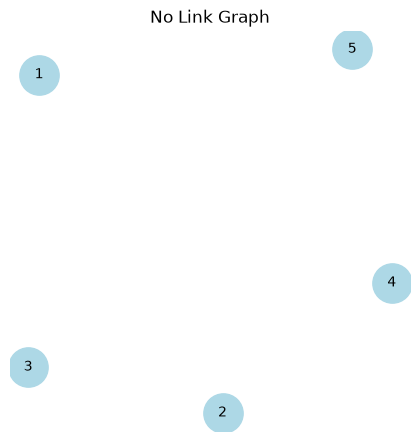

In [96]:
# No links
no_links = nx.Graph()
no_links.add_nodes_from([1, 2, 3, 4, 5]) 
plt.figure(figsize=(4, 4))
nx.draw(no_links, with_labels=True, node_color='lightblue', edge_color='gray', node_size=800, font_size=10)
plt.title("No Link Graph")
plt.show()

In [97]:
# Mine
print(compute_betweeness(no_links))
# Theirs 
print(nx.betweenness_centrality(no_links, normalized=False))

{1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
{1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0}


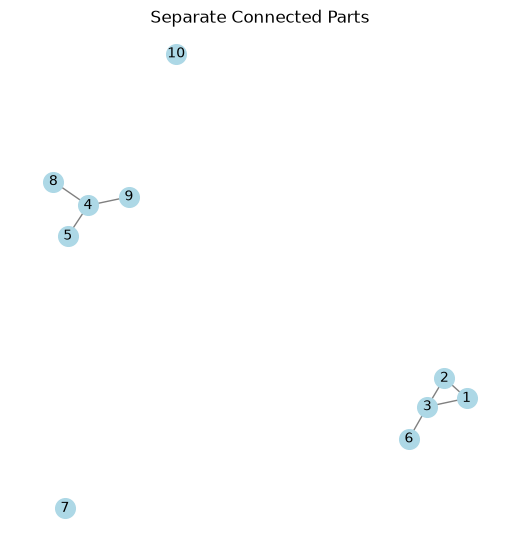

In [144]:
# Two connected components
two_connected = nx.Graph()

two_connected.add_nodes_from([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]) 
two_connected.add_edges_from([(1,2), (2,3), (4,5), (3,6), (1,3), (4,9), (4,8)])
plt.figure(figsize=(5, 5))
nx.draw(two_connected, with_labels=True, node_color='lightblue', edge_color='gray', node_size=200, font_size=10)
plt.title("Separate Connected Parts")
plt.show()

In [106]:
# Mine
print(compute_betweeness(two_connected))
# Theirs
print(nx.betweenness_centrality(two_connected, normalized=False))

print(compute_betweeness(two_connected) == nx.betweenness_centrality(two_connected, normalized=False))

{1: 0, 2: 0, 3: 2.0, 4: 3.0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0, 10: 0}
{1: 0.0, 2: 0.0, 3: 2.0, 4: 3.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0, 10: 0.0}
True


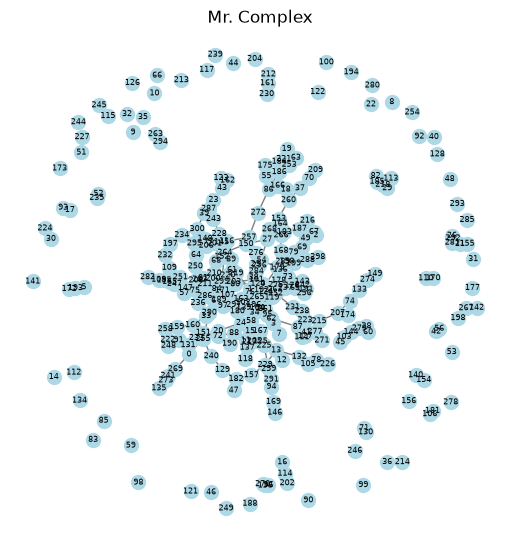

In [145]:
# More complex graph
import random

mister_complex = nx.Graph()

mister_complex.add_nodes_from(range(0,300)) 
for i in range(0,250):
    node_one = random.randint(0,300)
    node_two = random.randint(0,300)
    if node_one == node_two:
        continue
    mister_complex.add_edge(node_one, node_two)
plt.figure(figsize=(5, 5))
nx.draw(mister_complex, with_labels=True, node_color='lightblue', edge_color='gray', node_size=100, font_size=6)
plt.title("Mr. Complex")
plt.show()

In [109]:
# Mine
print(compute_betweeness(mister_complex))
# Theirs
print(nx.betweenness_centrality(mister_complex, normalized=False))

print(compute_betweeness(mister_complex) == nx.betweenness_centrality(mister_complex, normalized=False)) 
# ruh roh, not the same! 

{0: 1216.3333333333328, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 810.1666666666667, 9: 0, 10: 194.0, 11: 1302.8333333333328, 12: 0, 13: 1330.0, 14: 0, 15: 0, 16: 360.33333333333303, 17: 0, 18: 194.0, 19: 1597.166666666663, 20: 194.00000000000014, 21: 194.00000000000003, 22: 0, 23: 0, 24: 1.0, 25: 1397.1666666666656, 26: 194.0, 27: 376.6666666666664, 28: 0, 29: 1141.8333333333328, 30: 1486.3333333333323, 31: 1254.5, 32: 2331.999999999999, 33: 0, 34: 0, 35: 3319.66666666667, 36: 954.0, 37: 194.0, 38: 1496.0, 39: 768.0000000000008, 40: 0, 41: 0, 42: 0, 43: 0, 44: 0, 45: 576.0, 46: 576.0, 47: 2457.333333333333, 48: 0, 49: 576.0, 50: 0, 51: 0, 52: 0, 53: 194.00000000000003, 54: 0, 55: 11.0, 56: 0, 57: 0, 58: 0, 59: 580.3333333333343, 60: 0, 61: 926.3333333333342, 62: 937.3333333333338, 63: 194.0000000000001, 64: 820.0000000000002, 65: 0, 66: 386.0, 67: 194.0, 68: 4254.500000000023, 69: 0, 70: 0, 71: 1412.333333333331, 72: 0, 73: 194.0, 74: 0, 75: 1020.6666666666698, 76: 0, 77: 0, 78: 16

In [ ]:
# Who is the culprit?
my_results = compute_betweeness(mister_complex)
their_results = nx.betweenness_centrality(mister_complex, normalized=False)
for key, value in my_results.items():
    if value != their_results[key]:
        print("Found a bad one!")
        print(f"My results: {value} and theirs: {their_results[key]}")

# Looks like its that old crook, the ROUNDING ERROR!! 

Found a bad one!
My results: 1216.3333333333328 and theirs: 1216.333333333333
Found a bad one!
My results: 1302.8333333333328 and theirs: 1302.8333333333333
Found a bad one!
My results: 360.33333333333303 and theirs: 360.3333333333334
Found a bad one!
My results: 1597.166666666663 and theirs: 1597.1666666666663
Found a bad one!
My results: 194.00000000000014 and theirs: 194.0
Found a bad one!
My results: 194.00000000000003 and theirs: 194.0
Found a bad one!
My results: 1397.1666666666656 and theirs: 1397.1666666666663
Found a bad one!
My results: 376.6666666666664 and theirs: 376.6666666666665
Found a bad one!
My results: 1141.8333333333328 and theirs: 1141.8333333333333
Found a bad one!
My results: 1486.3333333333323 and theirs: 1486.333333333333
Found a bad one!
My results: 3319.66666666667 and theirs: 3319.666666666669
Found a bad one!
My results: 768.0000000000008 and theirs: 767.9999999999998
Found a bad one!
My results: 2457.333333333333 and theirs: 2457.333333333334
Found a bad 

In [111]:
# Let's nab him 
my_results_rounded = {key: round(val, 2) for key, val in my_results.items()}
their_results_rounded = {key: round(val, 2) for key, val in their_results.items()}
print(my_results_rounded == their_results_rounded) 

# Got him!!!!!!

True


### Question 3d

In [148]:
def test_betweenness_func(btwn_func):
    """
    This function tests a betweeness function.

    It tests both edgecases and correct cases, including:
    - Non-graph object 
    - Nodeless graph
    - Edgeless graph
    - Graph with one edge
    - Fully connected graph
    - Graph with multiple components
    - Complex random graph

    @param btwn_func (function): The function we want to test

    @return bool, error_message: whether or not the test suite succeeded, and error messages if it did not
    """

    # Non_graph object
    obj = object
    try:
        compute_betweeness(obj)
        return False, "Failed to throw exception when random python object was passed."
    except Exception as e:
        print(f"The following exception was properly thrown for random python object: {e}")

    # Test nodeless network
    d = nx.Graph()
    try:
        compute_betweeness(d)
        test_success = False
        return test_success, "Failed to throw exception when nodeless graph was passed."
    except Exception as e:
        print(f"The following exception was properly thrown for nodeless graph: {e}")

    # Edgeless graph
    edgeless =  nx.Graph()
    edgeless.add_nodes_from([1, 2, 3, 4, 5]) 

    if compute_betweeness(edgeless) != nx.betweenness_centrality(edgeless, normalized=False):
        return False, "Edgeless graph is not equivalent to NetworkX's edgeless graph."
    else:
        print("Passed no-edge network test.")
    
    # Graph with one edge
    one_edge =  nx.Graph()
    one_edge.add_nodes_from([1, 2, 3, 4, 5]) 
    one_edge.add_edge(3,5)
    
    if compute_betweeness(one_edge) != nx.betweenness_centrality(one_edge, normalized=False):
        return False, "One-edge graph is not equivalent to NetworkX's one-edge graph."
    else:
        print("Passed one-edge network test.")

    # Fully connected graph
    connected =  nx.Graph()
    connected.add_nodes_from([1, 2, 3, 4, 5]) 
    connected.add_edges_from([(1,2), (1,3), (1,4), (1,5), (2,3), (2,4), (2,5), (3,4), (3,5), (4,5)])
    
    if compute_betweeness(connected) != nx.betweenness_centrality(connected, normalized=False):
        return False, "Fully connected graph is not equivalent to NetworkX's fully connected graph."
    else:
        print("Passed fully connected network test.")

    # Graph with multiple components
    two_connected = nx.Graph()
    two_connected.add_nodes_from([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]) 
    two_connected.add_edges_from([(1,2), (2,3), (4,5), (3,6), (1,3), (4,9), (4,8)])

    if compute_betweeness(connected) != nx.betweenness_centrality(connected, normalized=False):
        return False, "Multicomponent graph is not equivalent to NetworkX's multicomponent graph."
    else:
        print("Passed multicomponent network test.")

    # Complex random graph
    mister_complex = nx.Graph()

    mister_complex.add_nodes_from(range(0,300)) 
    for i in range(0,250):
        node_one = random.randint(0,300)
        node_two = random.randint(0,300)
        if node_one == node_two:
            continue
        mister_complex.add_edge(node_one, node_two)
        
    our_results = compute_betweeness(mister_complex)
    their_results = nx.betweenness_centrality(mister_complex, normalized=False)

    my_results_rounded = {key: round(val, 2) for key, val in our_results.items()}
    their_results_rounded = {key: round(val, 2) for key, val in their_results.items()}

    if my_results_rounded != their_results_rounded:
        return False, "Complex graph is not equivalent to NetworkX's complex graph. Yes, we checked rounding error."
    else:
        print("Passed complex network test.")

    return True, "All tests passed! Great job."


In [150]:
res, message = test_betweenness_func(compute_betweeness)
print(f"Result is: {res}: {message}")

The following exception was properly thrown for random python object: Network must be NetworkX graph.
The following exception was properly thrown for nodeless graph: Network must have nodes.
Passed no-edge network test.
Passed one-edge network test.
Passed fully connected network test.
Passed multicomponent network test.
Passed complex network test.
Result is: True: All tests passed! Great job.


## Question 4